In [1]:
from pyspark.sql import SparkSession
spark = SparkSession.builder.getOrCreate()

In [2]:
df = spark.read.csv("hdfs://localhost:9000//data/new_retail_data.csv", header=True, inferSchema=True)
df.printSchema()

root
 |-- Transaction_ID: double (nullable = true)
 |-- Customer_ID: double (nullable = true)
 |-- Name: string (nullable = true)
 |-- Email: string (nullable = true)
 |-- Phone: double (nullable = true)
 |-- Address: string (nullable = true)
 |-- City: string (nullable = true)
 |-- State: string (nullable = true)
 |-- Zipcode: double (nullable = true)
 |-- Country: string (nullable = true)
 |-- Age: double (nullable = true)
 |-- Gender: string (nullable = true)
 |-- Income: string (nullable = true)
 |-- Customer_Segment: string (nullable = true)
 |-- Date: string (nullable = true)
 |-- Year: double (nullable = true)
 |-- Month: string (nullable = true)
 |-- Time: timestamp (nullable = true)
 |-- Total_Purchases: double (nullable = true)
 |-- Amount: double (nullable = true)
 |-- Total_Amount: double (nullable = true)
 |-- Product_Category: string (nullable = true)
 |-- Product_Brand: string (nullable = true)
 |-- Product_Type: string (nullable = true)
 |-- Feedback: string (nullable =

In [3]:
df.createOrReplaceTempView("Retails")

In [4]:
df.show(1)

+--------------+-----------+-------------------+-----------------+-------------+-----------------+--------+------+-------+-------+----+------+------+----------------+---------+------+---------+-------------------+---------------+-----------+------------+----------------+-------------+------------+---------+---------------+--------------+------------+-------+--------------+
|Transaction_ID|Customer_ID|               Name|            Email|        Phone|          Address|    City| State|Zipcode|Country| Age|Gender|Income|Customer_Segment|     Date|  Year|    Month|               Time|Total_Purchases|     Amount|Total_Amount|Product_Category|Product_Brand|Product_Type| Feedback|Shipping_Method|Payment_Method|Order_Status|Ratings|      products|
+--------------+-----------+-------------------+-----------------+-------------+-----------------+--------+------+-------+-------+----+------+------+----------------+---------+------+---------+-------------------+---------------+-----------+-------

# 1. Get the order count per customer for January 2024.
* Tables - orders and customers
* Data should be sorted in descending order by count and ascending order by customer ID.
* Output should contain customer_id, customer_first_name, customer_last_name and customer_order_count.

In [5]:
spark.sql("""with orders as(
    select
        transaction_id,
        customer_id,
        replace(trim(name),'. ','.') as name,
        year,
        month
    from Retails
)

select
    customer_id,
    substring(left(name, locate(' ',name)),locate('.',(left(name, locate(' ',name)))) + 1,100)  as customer_first_name,
    trim(reverse(left(reverse(name),locate(' ',reverse(name))))) as customer_last_name,
    count(transaction_id) as customer_order_count
from orders
where year = 2024 and month = 'January'
group by customer_id, customer_first_name, customer_last_name
order by customer_order_count desc, customer_id
""").show()

+-----------+-------------------+------------------+--------------------+
|customer_id|customer_first_name|customer_last_name|customer_order_count|
+-----------+-------------------+------------------+--------------------+
|    10615.0|            Dennis |             Reyes|                   2|
|    10625.0|             Kevin |             Welch|                   2|
|    11422.0|           Heather |          Peterson|                   2|
|    12104.0|            Meagan |             Ellis|                   2|
|    12226.0|             David |             Carey|                   2|
|    12957.0|          Jennifer |         Contreras|                   2|
|    13199.0|           Sabrina |          Franklin|                   2|
|    13486.0|             Emily |          Copeland|                   2|
|    13546.0|            Ashley |            Santos|                   2|
|    14151.0|             Carla |              Mata|                   2|
|    14183.0|            Travis |     

# 2. Get the customer details of those who have not placed any orders in January 2024.
* Tables - orders and customers
* Data should be sorted in ascending order by customer_id
* Output should contain all the fields from the customers
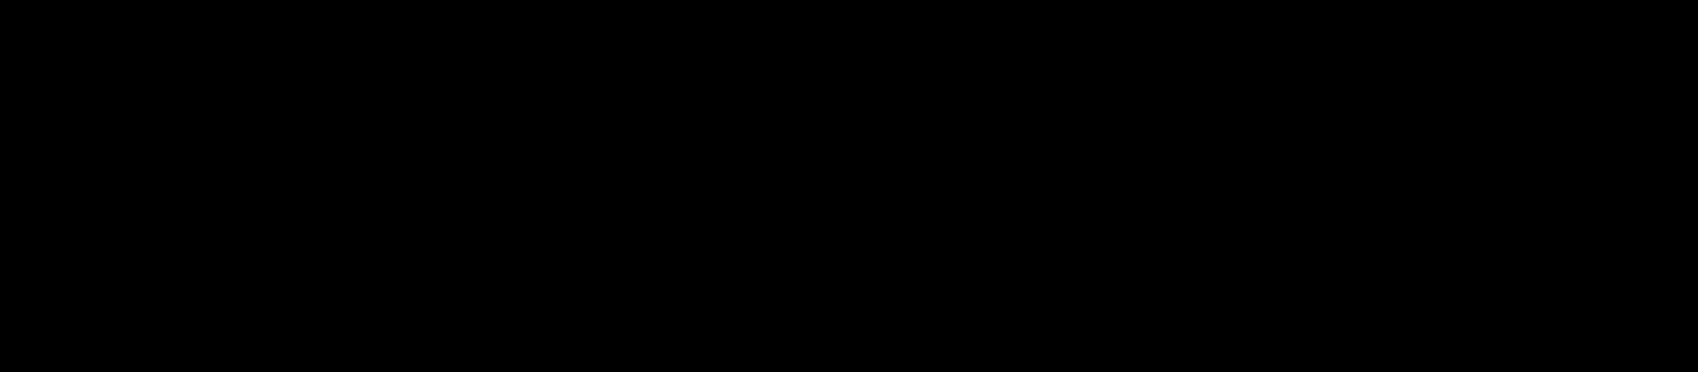

In [6]:
spark.sql("""
with customers as(
    select distinct name, *
    from retails
)

select c.*
from customers c
where not exists (
    select *
    from Retails r
    where r.customer_id = c.customer_id and r.name = c.name
      and r.year = 2024
      and r.month = 'January'
)
""").show()

+-------------------+--------------+-----------+-------------------+--------------------+-------------+--------------------+----------+---------------+-------+---------+----+------+------+----------------+----------+------+---------+-------------------+---------------+-----------+------------+----------------+-----------------+------------+---------+---------------+--------------+------------+-------+--------------------+
|               name|Transaction_ID|Customer_ID|               Name|               Email|        Phone|             Address|      City|          State|Zipcode|  Country| Age|Gender|Income|Customer_Segment|      Date|  Year|    Month|               Time|Total_Purchases|     Amount|Total_Amount|Product_Category|    Product_Brand|Product_Type| Feedback|Shipping_Method|Payment_Method|Order_Status|Ratings|            products|
+-------------------+--------------+-----------+-------------------+--------------------+-------------+--------------------+----------+-------------

# 3. Get the revenue generated by each customer for January 2024
* Tables - orders, order_items, and customers
* Data should be sorted in descending order by revenue and then ascending order by
customer_id.
* Output should contain customer_id, customer_first_name, customer_last_name,
customer_revenue.
* If the customer places no orders, then the corresponding revenue for a given customer
should be 0.
* Consider only COMPLETE and CLOSED orders

In [7]:
spark.sql("""
with customers as(
    select
        distinct name,
        customer_id,
        substring(left(replace(name,'. ','.'), locate(' ',replace(name,'. ','.'))),locate('.',(left(replace(name,'. ','.'), locate(' ',replace(name,'. ','.'))))) + 1,100) as customer_first_name,
        trim(reverse(left(reverse(name),locate(' ',reverse(name))))) as customer_last_name
        from Retails
)

select r.customer_id, c.customer_first_name, c.customer_last_name, sum(r.total_amount) as customer_revenue
from retails r
inner join customers c on r.customer_id = c.customer_id and r.name = c.name
where r.year = 2024 and r.month = 'January' and r.order_status in ('Shipped', 'Delivered')
group by r.customer_id, c.customer_first_name, c.customer_last_name
order by customer_revenue desc, customer_id
""").show()

+-----------+-------------------+------------------+----------------+
|customer_id|customer_first_name|customer_last_name|customer_revenue|
+-----------+-------------------+------------------+----------------+
|    27260.0|           Michael |            Carter|     8588.484076|
|    65208.0|             Haley |           Bullock|      7939.73228|
|    13486.0|             Emily |          Copeland|     7679.671776|
|    54175.0|         Stephanie |             Perry|     7178.143402|
|    44000.0|            Xavier |            Mooney|     6661.707542|
|    65123.0|          Jennifer |                MD|     5738.794198|
|    84368.0|           Charles |           Spencer|      5486.89298|
|    12226.0|             David |             Carey|     5152.428512|
|    43939.0|              Dawn |             Hayes|     5041.813946|
|    18011.0|             James |              Lamb|     4990.599062|
|    93283.0|            Pamela |             Garza|     4979.550651|
|    18258.0|       

# 4. Get the revenue generated for each category for January 2024
* Tables - orders, order_items, products and categories
* Data should be sorted in ascending order by category_id.
* Output should contain all the fields from the category along with the revenue as
category_revenue.
* Consider only COMPLETE and CLOSED orders

In [8]:
spark.sql("""
select
    distinct product_category,
    count(product_type) as product_type_count,
    sum(total_amount) as category_revenue
from Retails
where order_status in ('Shipped', 'Delivered')
group by product_category
order by product_category
""").show()

+----------------+------------------+--------------------+
|product_category|product_type_count|    category_revenue|
+----------------+------------------+--------------------+
|            NULL|               168|  222942.91737619002|
|           Books|             34179|4.6916995615848996E7|
|        Clothing|             34301| 4.668465156510588E7|
|     Electronics|             50527| 6.909362538007186E7|
|         Grocery|             42028| 5.742335846127027E7|
|      Home Decor|             34270|4.6846480884450875E7|
+----------------+------------------+--------------------+



# 5. Get the products for each department. --> Làm ở bt3-mariadb.ipynb
* a. Tables - departments, categories, products
* b. Data should be sorted in ascending order by department_id
* c. The output should contain all the fields from the department and the product count as product_count